# Car Crash Severity Classification
## Machine Learning Project

**Objective:** Predict the severity of a car crash (`Minor Injury`, `Severe Injury`, or `Fatal`) based on crash conditions, vehicle information, and driver behaviour.

**Dataset:**
- Training set: 4,000 labelled records
- Test set: 1,000 records (labels used for Kaggle evaluation)
- Target variable: `Severity` (3 classes)

**Models to be implemented:**
- K-Nearest Neighbours (KNN)
- Decision Tree
- Random Forest
- Logistic Regression
- Naïve Bayes
- (Extra) Gradient Boosting

In [1]:
# ─────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

# Classifiers
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

---
## 1. Load the Data

In [3]:
# Load training and test sets
train_df = pd.read_csv("car_crash_train.csv")
test_df  = pd.read_csv("car_crash_test.csv")

print("Training set shape:", train_df.shape)
print("Test set shape    :", test_df.shape)

train_df.head()

Training set shape: (4000, 19)
Test set shape    : (1000, 19)


,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Weather Conditions,Road Conditions,Crash Type,Vehicle Type,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),Distraction Level,Time of Day,Traffic Density,Visibility Distance (m),Severity
0,182,69,Yes,No,Clear,Dry,Rollover,Sedan,5,Good,Good,23,11,0.025314,NaN,Morning,Low,213,Minor Injury
1,192,73,Yes,No,Clear,Dry,Head-on,Truck,3,Good,Good,29,27,0.002372,Phone,Morning,Medium,426,Minor Injury
2,114,77,No,Yes,Clear,Dry,Head-on,Sedan,16,Good,Worn out,73,45,0.000483,NaN,Morning,Medium,175,Minor Injury
3,93,14,No,Yes,Clear,Dry,Rear-end,Truck,14,Worn out,Worn out,27,18,0.176578,NaN,Afternoon,Medium,82,Minor Injury
4,170,96,No,Yes,Clear,Dry,Side impact,SUV,15,Good,Good,70,27,0.065696,Other,Morning,Medium,96,Severe Injury


---
## 2. Exploratory Data Analysis (EDA)

We explore the dataset to understand:
- The distribution of the target variable
- The types and ranges of features
- Missing values
- Relationships between features and crash severity

In [4]:
# Basic information about the training data
print("=== Data Types & Non-Null Counts ===")
train_df.info()

print("\n=== Statistical Summary (Numerical Features) ===")
train_df.describe().round(2)

=== Data Types & Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Crash Speed (km/h)         4000 non-null   int64  
 1   Impact Angle (degrees)     4000 non-null   int64  
 2   Airbag Deployed            4000 non-null   object 
 3   Seatbelt Used              4000 non-null   object 
 4   Weather Conditions         4000 non-null   object 
 5   Road Conditions            4000 non-null   object 
 6   Crash Type                 4000 non-null   object 
 7   Vehicle Type               4000 non-null   object 
 8   Vehicle Age (years)        4000 non-null   int64  
 9   Brake Condition            4000 non-null   object 
 10  Tire Condition             4000 non-null   object 
 11  Driver Age                 4000 non-null   int64  
 12  Driver Experience (years)  4000 non-null   int64  
 13  Alcohol Lev

,Crash Speed (km/h),Impact Angle (degrees),Vehicle Age (years),Driver Age,Driver Experience (years),Alcohol Level (BAC%),Visibility Distance (m)
count,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,111.00,89.98,9.45,48.70,24.72,0.10,247.58
std,52.23,51.30,5.72,17.82,14.21,0.06,143.48
min,20.00,0.00,0.00,18.00,0.00,0.00,10.00
25%,66.00,45.00,5.00,34.00,13.00,0.05,120.00
50%,112.00,89.50,9.00,49.00,25.00,0.10,244.00
75%,157.00,134.00,14.00,64.00,37.00,0.15,372.00
max,199.00,179.00,19.00,79.00,49.00,0.20,499.00


In [5]:
# Check for missing values
missing = train_df.isnull().sum()
missing = missing[missing > 0]

print("=== Missing Values ===")
print(missing)
print(f"\nNote: 'Distraction Level' has {missing['Distraction Level']} missing values "
      f"({missing['Distraction Level']/len(train_df)*100:.1f}% of training data).")
print("These represent cases where no distraction was recorded — we will fill them with 'None'.")

=== Missing Values ===
Distraction Level    2360
dtype: int64

Note: 'Distraction Level' has 2360 missing values (59.0% of training data).
These represent cases where no distraction was recorded — we will fill them with 'None'.


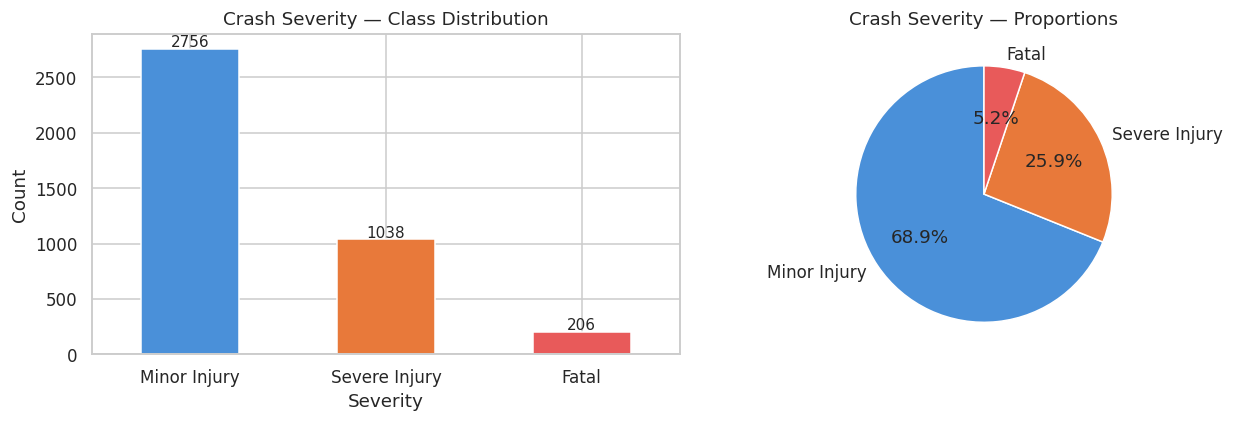


Class distribution:
Severity
Minor Injury     2756
Severe Injury    1038
Fatal             206
Name: count, dtype: int64

Note: The dataset is imbalanced — 'Minor Injury' dominates at ~69%.
This means accuracy alone can be misleading; we will also use precision, recall, and F1-score.


In [6]:
# Target variable distribution
severity_counts = train_df["Severity"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
severity_counts.plot(kind="bar", ax=axes[0], color=["#4A90D9", "#E8793A", "#E85A5A"], edgecolor="white")
axes[0].set_title("Crash Severity — Class Distribution")
axes[0].set_xlabel("Severity")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
for bar, count in zip(axes[0].patches, severity_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(count), ha="center", fontsize=10)

# Pie chart
axes[1].pie(severity_counts, labels=severity_counts.index,
            autopct="%1.1f%%", colors=["#4A90D9", "#E8793A", "#E85A5A"],
            startangle=90, wedgeprops={"edgecolor": "white"})
axes[1].set_title("Crash Severity — Proportions")

plt.tight_layout()
plt.show()

print("\nClass distribution:")
print(severity_counts)
print("\nNote: The dataset is imbalanced — 'Minor Injury' dominates at ~69%.")
print("This means accuracy alone can be misleading; we will also use precision, recall, and F1-score.")

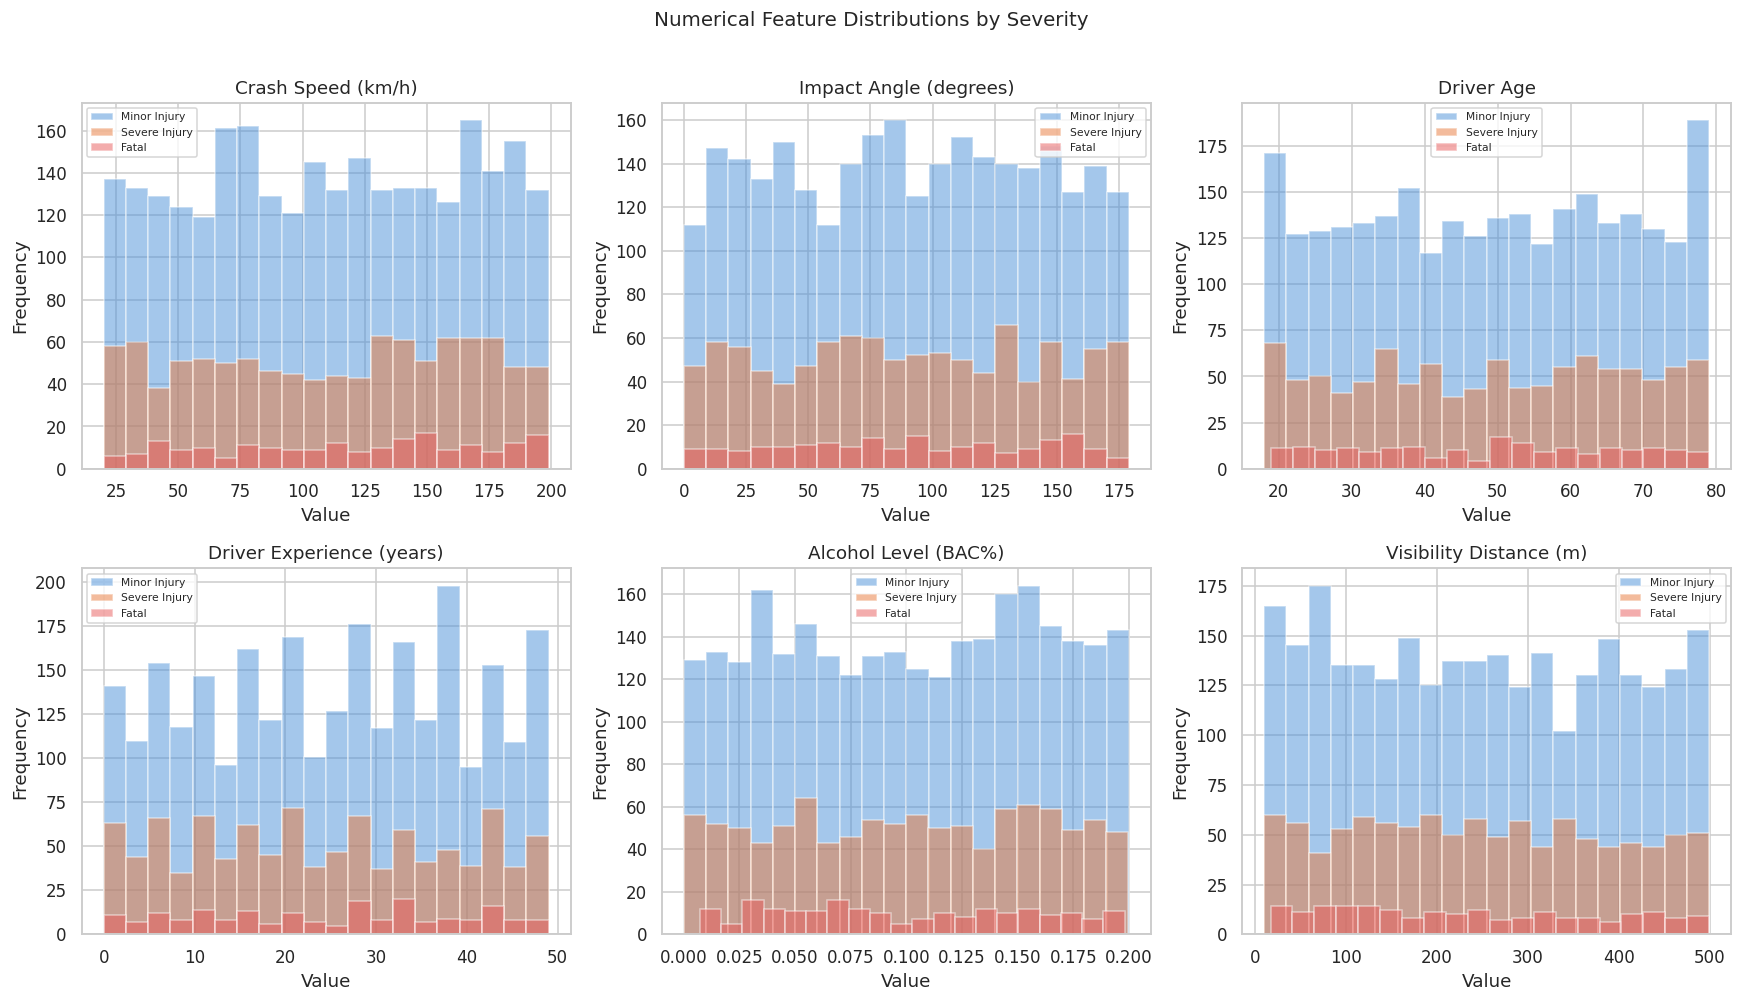

In [7]:
# Distribution of numerical features by severity
num_cols = ["Crash Speed (km/h)", "Impact Angle (degrees)", "Driver Age",
            "Driver Experience (years)", "Alcohol Level (BAC%)", "Visibility Distance (m)"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for severity, color in zip(["Minor Injury", "Severe Injury", "Fatal"],
                                ["#4A90D9", "#E8793A", "#E85A5A"]):
        subset = train_df[train_df["Severity"] == severity][col]
        axes[i].hist(subset, bins=20, alpha=0.5, label=severity, color=color, edgecolor="white")
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")
    axes[i].legend(fontsize=7)

plt.suptitle("Numerical Feature Distributions by Severity", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

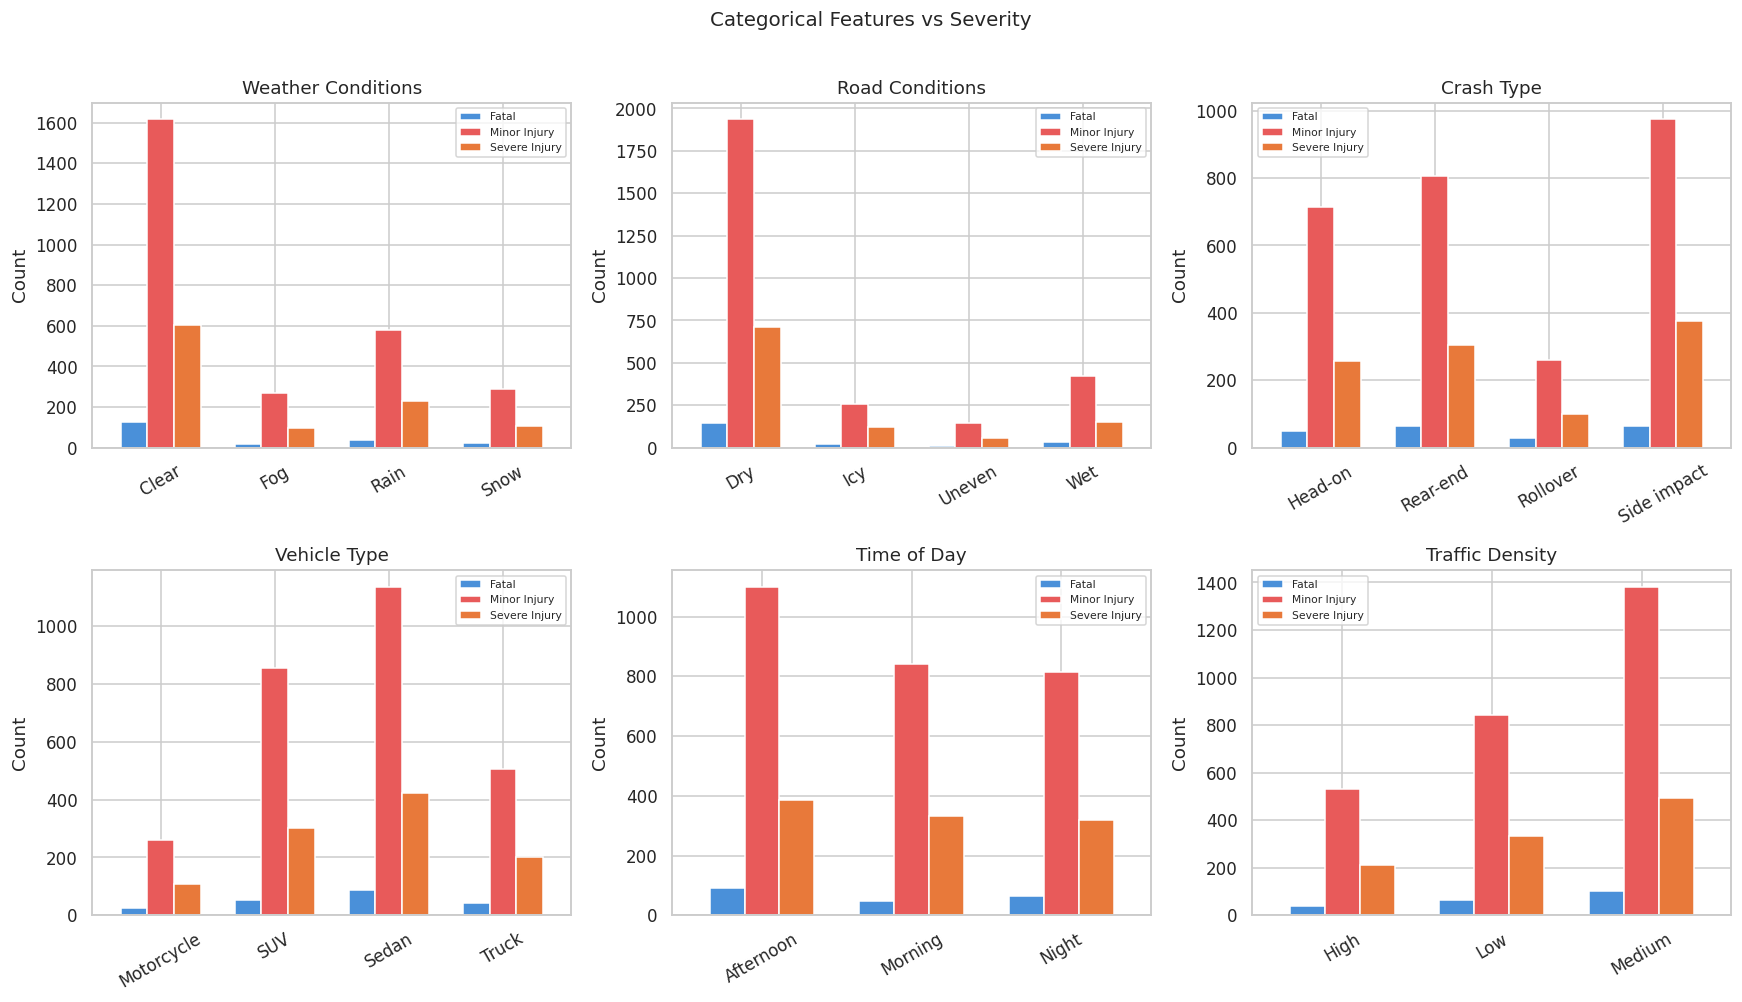

In [8]:
# Categorical feature counts by severity
cat_cols = ["Weather Conditions", "Road Conditions", "Crash Type",
            "Vehicle Type", "Time of Day", "Traffic Density"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(train_df[col], train_df["Severity"])
    ct.plot(kind="bar", ax=axes[i], color=["#4A90D9", "#E85A5A", "#E8793A"],
            edgecolor="white", width=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].legend(fontsize=7)

plt.suptitle("Categorical Features vs Severity", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

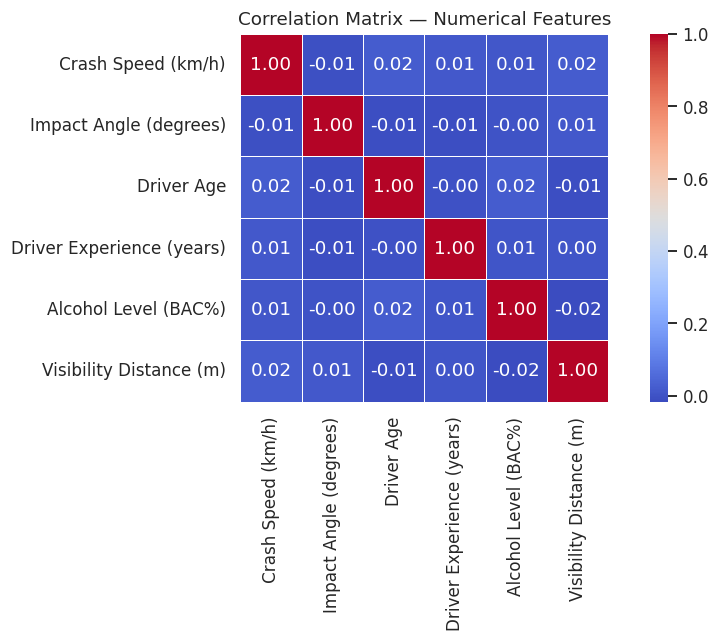

Note: Numerical features show low correlation with each other,
meaning each contributes relatively independent information to the model.


In [9]:
# Correlation heatmap for numerical features
num_df = train_df[num_cols].copy()

plt.figure(figsize=(9, 6))
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, square=True)
plt.title("Correlation Matrix — Numerical Features")
plt.tight_layout()
plt.show()

print("Note: Numerical features show low correlation with each other,")
print("meaning each contributes relatively independent information to the model.")

---
## 3. Preprocessing

Steps:
1. Fill missing `Distraction Level` values with `"None"` (NaN means no distraction was recorded)
2. Encode binary categorical columns (Yes/No) as 0/1
3. One-hot encode multi-class categorical columns
4. Separate features (X) and target (y)
5. Encode the target labels as integers
6. Apply the same transformations to the test set

In [10]:
# ─────────────────────────────────────────────
# PREPROCESSING
# ─────────────────────────────────────────────

# Work on copies so originals are preserved
train = train_df.copy()
test  = test_df.copy()

# 1. Fill missing Distraction Level
train["Distraction Level"] = train["Distraction Level"].fillna("None")
test["Distraction Level"]  = test["Distraction Level"].fillna("None")

# 2. Encode binary Yes/No columns as 0/1
binary_cols = ["Airbag Deployed", "Seatbelt Used", "Brake Condition", "Tire Condition"]
binary_map  = {"Yes": 1, "No": 0, "Good": 1, "Worn out": 0}

for col in binary_cols:
    train[col] = train[col].map(binary_map)
    test[col]  = test[col].map(binary_map)

# 3. One-hot encode multi-class categorical columns
ohe_cols = ["Weather Conditions", "Road Conditions", "Crash Type",
            "Vehicle Type", "Distraction Level", "Time of Day", "Traffic Density"]

# Combine train and test before encoding to ensure identical columns
train["_split"] = "train"
test["_split"]  = "test"

# Temporarily drop Severity for alignment
test_severity = test["Severity"].copy()   # keep test labels aside
combined = pd.concat([train, test], axis=0, ignore_index=True)

# One-hot encode
combined = pd.get_dummies(combined, columns=ohe_cols, drop_first=False)

# Split back
train_processed = combined[combined["_split"] == "train"].drop("_split", axis=1)
test_processed  = combined[combined["_split"] == "test"].drop("_split", axis=1)

# 4. Separate features and target
TARGET = "Severity"
X_train_full = train_processed.drop(TARGET, axis=1)
y_train_full = train_processed[TARGET]

X_test = test_processed.drop(TARGET, axis=1)
y_test  = test_severity   # actual labels from test set (used for local evaluation)

# 5. Encode target labels
le = LabelEncoder()
y_train_full_enc = le.fit_transform(y_train_full)
y_test_enc       = le.transform(y_test)

print("Classes:", le.classes_)
print("Encoded as:", list(range(len(le.classes_))))
print("\nFinal feature matrix shape (train):", X_train_full.shape)
print("Final feature matrix shape (test) :", X_test.shape)
print("\nPreprocessing complete.")

Classes: ['Fatal' 'Minor Injury' 'Severe Injury']
Encoded as: [0, 1, 2]

Final feature matrix shape (train): (4000, 37)
Final feature matrix shape (test) : (1000, 37)

Preprocessing complete.


In [11]:
# Split training data into train and validation sets (80/20)
# The test set is reserved for Kaggle submission only
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full_enc,
    test_size=0.2, random_state=42, stratify=y_train_full_enc
)

print("Training samples  :", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples      :", len(X_test))

Training samples  : 3200
Validation samples: 800
Test samples      : 1000


In [12]:
# Scale numerical features — required for KNN and Logistic Regression
# Tree-based models don't require scaling but it doesn't hurt them
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit only on training data
X_val_scaled   = scaler.transform(X_val)          # apply same scale to validation
X_test_scaled  = scaler.transform(X_test)         # apply same scale to test

# Also scale full training set for final model retraining
X_train_full_scaled = scaler.fit_transform(X_train_full)

---
## 4. Helper Function — Evaluation

We define a reusable function that prints the classification report and plots the confusion matrix for any model.

In [14]:
def evaluate_model(name, y_true, y_pred, classes):
    """Print classification report and plot confusion matrix."""
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}\n")
    print(classification_report(y_true, y_pred, target_names=classes))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()

# Store results for final comparison
results = {}
CLASS_NAMES = le.classes_

---
## 5. Classification Models

### 5.1 K-Nearest Neighbours (KNN)

KNN classifies a point by looking at the K closest training points and taking a majority vote.
It is a distance-based, non-parametric algorithm — it makes no assumptions about the data distribution.
Scaling is essential because features with larger ranges would otherwise dominate the distance calculation.

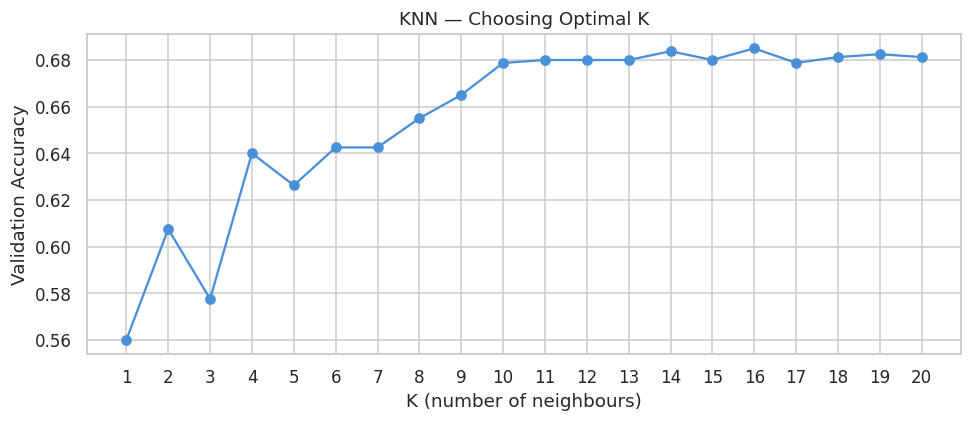

Best K = 16  |  Validation Accuracy = 0.6850

  K-Nearest Neighbours (K=16)
Accuracy: 0.6850

               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.69      0.99      0.81       551
Severe Injury       0.25      0.01      0.02       208

     accuracy                           0.69       800
    macro avg       0.31      0.33      0.28       800
 weighted avg       0.54      0.69      0.56       800



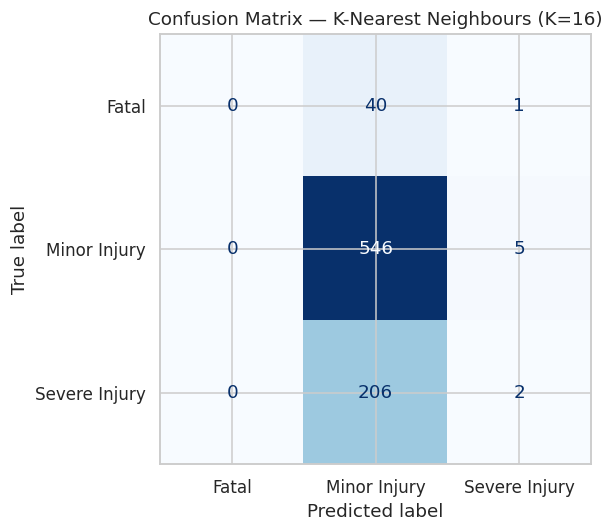

In [15]:
# ─── K-Nearest Neighbours ───────────────────
# We test several values of K and pick the best one on the validation set

k_values = range(1, 21)
val_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    val_accuracies.append(accuracy_score(y_val, knn.predict(X_val_scaled)))

# Plot K vs accuracy
plt.figure(figsize=(9, 4))
plt.plot(k_values, val_accuracies, marker="o", color="#4A90D9")
plt.xlabel("K (number of neighbours)")
plt.ylabel("Validation Accuracy")
plt.title("KNN — Choosing Optimal K")
plt.xticks(k_values)
plt.tight_layout()
plt.show()

best_k = k_values[np.argmax(val_accuracies)]
print(f"Best K = {best_k}  |  Validation Accuracy = {max(val_accuracies):.4f}")

# Train final KNN with best K
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred_knn = knn_best.predict(X_val_scaled)

evaluate_model("K-Nearest Neighbours (K={})".format(best_k), y_val, y_pred_knn, CLASS_NAMES)
results["KNN"] = accuracy_score(y_val, y_pred_knn)

### 5.2 Decision Tree

A Decision Tree learns a set of if/else rules by recursively splitting the data on the feature
that gives the best information gain (or Gini impurity reduction) at each step.
It is interpretable and requires no scaling, but is prone to overfitting if not constrained.
We use `max_depth` to limit tree depth and prevent overfitting.

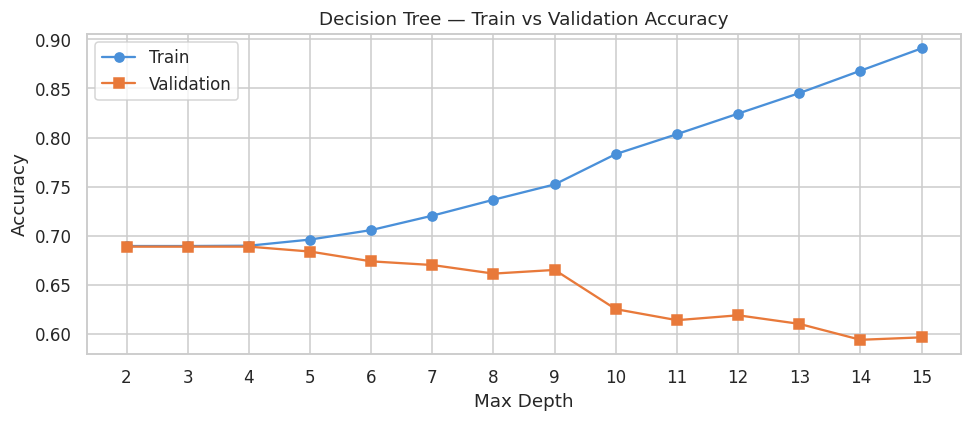

Best max_depth = 2  |  Validation Accuracy = 0.6887

  Decision Tree (max_depth=2)
Accuracy: 0.6887

               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.69      1.00      0.82       551
Severe Injury       0.00      0.00      0.00       208

     accuracy                           0.69       800
    macro avg       0.23      0.33      0.27       800
 weighted avg       0.47      0.69      0.56       800



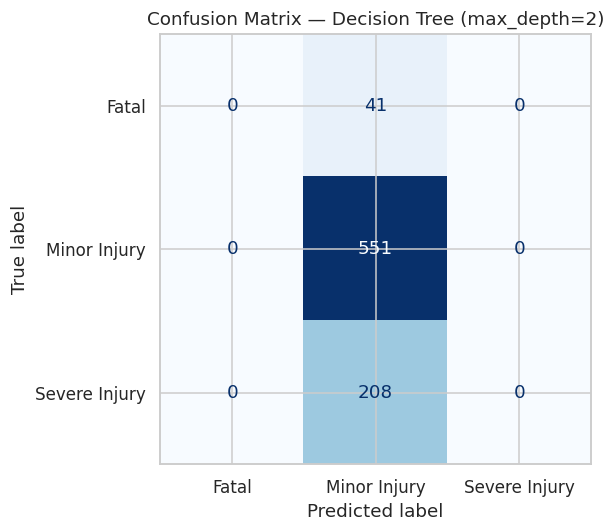

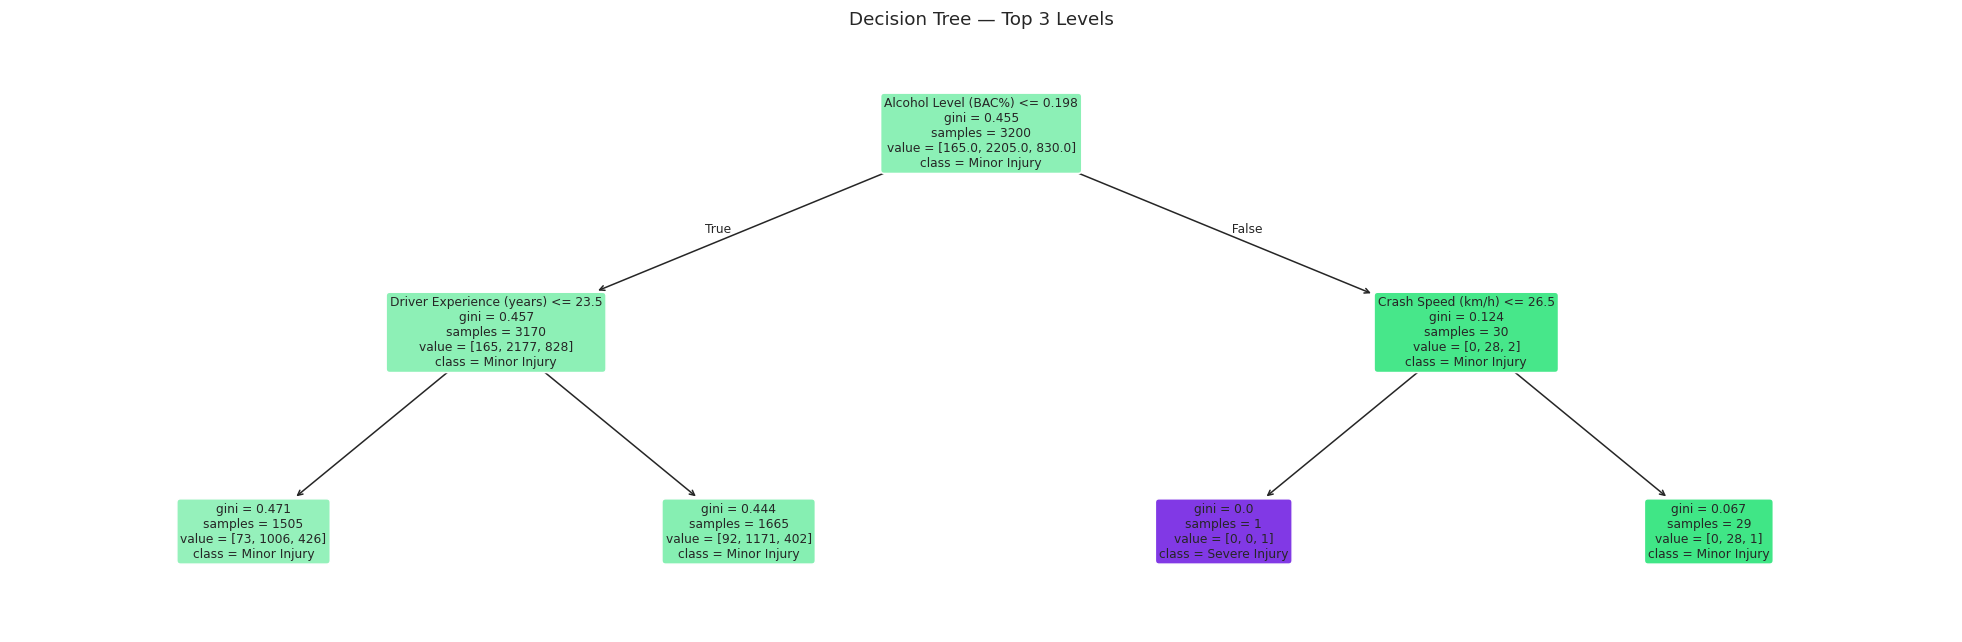

In [16]:
# ─── Decision Tree ──────────────────────────
# Tune max_depth to avoid overfitting
depth_values = range(2, 16)
train_accs, val_accs = [], []

for d in depth_values:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, dt.predict(X_train)))
    val_accs.append(accuracy_score(y_val, dt.predict(X_val)))

plt.figure(figsize=(9, 4))
plt.plot(depth_values, train_accs, marker="o", label="Train", color="#4A90D9")
plt.plot(depth_values, val_accs,   marker="s", label="Validation", color="#E8793A")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree — Train vs Validation Accuracy")
plt.legend()
plt.xticks(depth_values)
plt.tight_layout()
plt.show()

best_depth = depth_values[np.argmax(val_accs)]
print(f"Best max_depth = {best_depth}  |  Validation Accuracy = {max(val_accs):.4f}")

dt_best = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_best.fit(X_train, y_train)
y_pred_dt = dt_best.predict(X_val)

evaluate_model(f"Decision Tree (max_depth={best_depth})", y_val, y_pred_dt, CLASS_NAMES)
results["Decision Tree"] = accuracy_score(y_val, y_pred_dt)

# Visualise top 3 levels of the tree
plt.figure(figsize=(18, 6))
plot_tree(dt_best, max_depth=3, feature_names=X_train.columns.tolist(),
          class_names=CLASS_NAMES, filled=True, rounded=True, fontsize=8)
plt.title("Decision Tree — Top 3 Levels")
plt.tight_layout()
plt.show()

### 5.3 Random Forest

Random Forest is an ensemble of many Decision Trees, each trained on a random subset of the data
and a random subset of features (bagging). The final prediction is made by majority vote.
It reduces overfitting compared to a single tree and generally achieves much higher accuracy.


  Random Forest (200 trees)
Accuracy: 0.6887

               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.69      1.00      0.82       551
Severe Injury       0.00      0.00      0.00       208

     accuracy                           0.69       800
    macro avg       0.23      0.33      0.27       800
 weighted avg       0.47      0.69      0.56       800



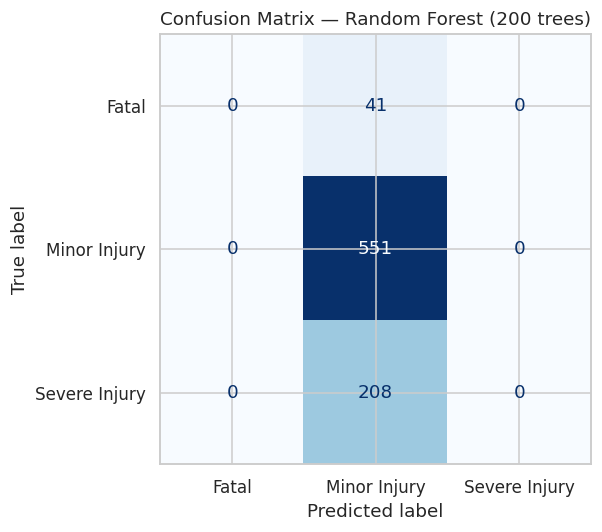

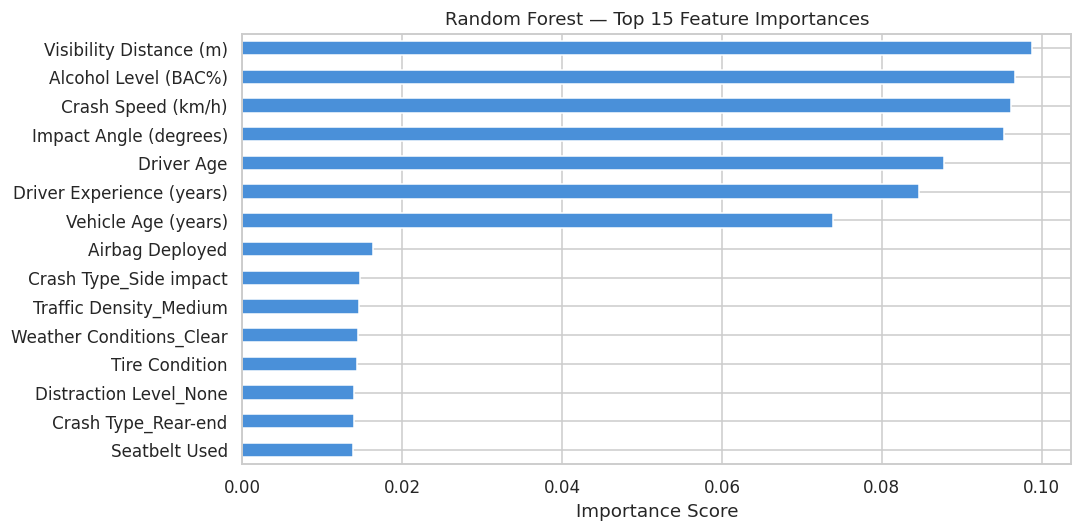

In [17]:
# ─── Random Forest ──────────────────────────
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)

evaluate_model("Random Forest (200 trees)", y_val, y_pred_rf, CLASS_NAMES)
results["Random Forest"] = accuracy_score(y_val, y_pred_rf)

# Feature importance
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top_features = importances.nlargest(15)

plt.figure(figsize=(10, 5))
top_features.sort_values().plot(kind="barh", color="#4A90D9", edgecolor="white")
plt.title("Random Forest — Top 15 Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

### 5.4 Logistic Regression

Despite the name, Logistic Regression is a classification algorithm.
It models the probability of each class using a sigmoid (or softmax for multi-class) function.
It is a linear model — it works best when the decision boundary between classes is roughly linear.
Scaling is required because it is sensitive to feature magnitude.


  Logistic Regression
Accuracy: 0.6887

               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.69      1.00      0.82       551
Severe Injury       0.00      0.00      0.00       208

     accuracy                           0.69       800
    macro avg       0.23      0.33      0.27       800
 weighted avg       0.47      0.69      0.56       800



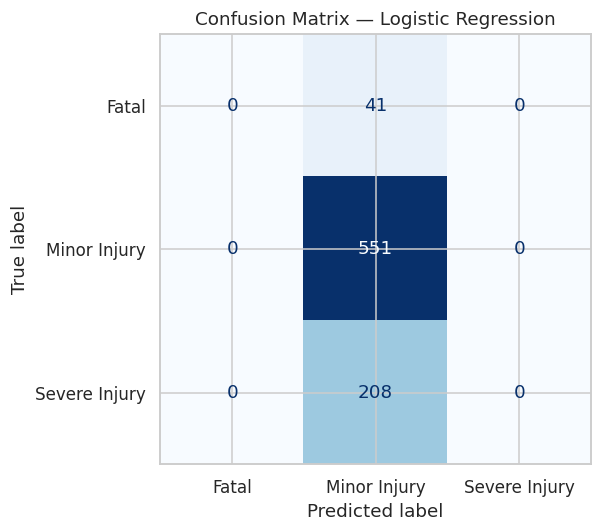

In [18]:
# ─── Logistic Regression ────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42, multi_class="multinomial")
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_val_scaled)

evaluate_model("Logistic Regression", y_val, y_pred_lr, CLASS_NAMES)
results["Logistic Regression"] = accuracy_score(y_val, y_pred_lr)

### 5.5 Naïve Bayes

Naïve Bayes applies Bayes' theorem with the "naïve" assumption that all features are
conditionally independent given the class. Despite this unrealistic assumption, it often performs
well in practice. `GaussianNB` assumes that numerical features follow a normal distribution.


  Naïve Bayes (Gaussian)
Accuracy: 0.6400

               precision    recall  f1-score   support

        Fatal       0.09      0.05      0.06        41
 Minor Injury       0.69      0.90      0.78       551
Severe Injury       0.28      0.08      0.12       208

     accuracy                           0.64       800
    macro avg       0.35      0.34      0.32       800
 weighted avg       0.55      0.64      0.57       800



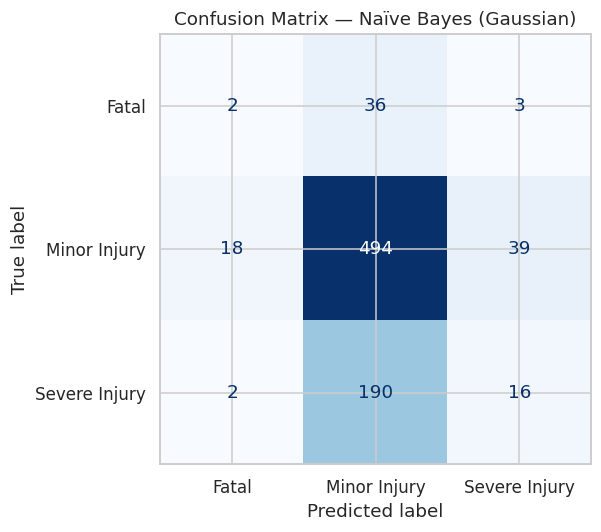

In [19]:
# ─── Naïve Bayes ────────────────────────────
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
y_pred_nb = nb.predict(X_val_scaled)

evaluate_model("Naïve Bayes (Gaussian)", y_val, y_pred_nb, CLASS_NAMES)
results["Naïve Bayes"] = accuracy_score(y_val, y_pred_nb)

### 5.6 (Extra) Gradient Boosting

Gradient Boosting is a more advanced ensemble method. Unlike Random Forest (parallel trees),
it builds trees sequentially — each tree corrects the errors of the previous one.
It typically achieves state-of-the-art performance on tabular datasets.


  Gradient Boosting
Accuracy: 0.6525

               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.69      0.92      0.79       551
Severe Injury       0.22      0.06      0.10       208

     accuracy                           0.65       800
    macro avg       0.30      0.33      0.30       800
 weighted avg       0.53      0.65      0.57       800



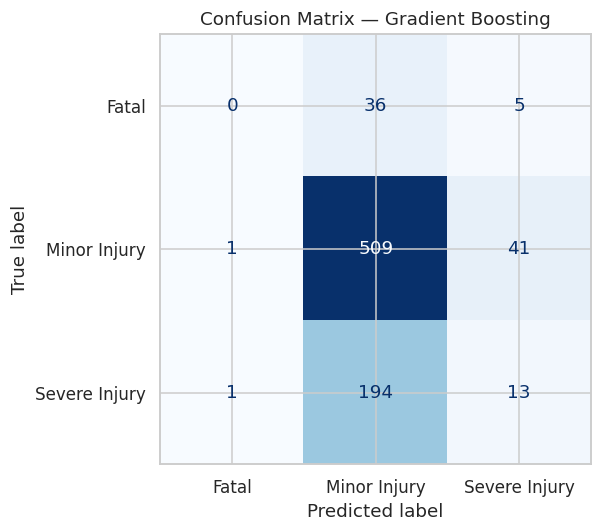

In [20]:
# ─── Gradient Boosting (Extra) ──────────────
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                 max_depth=4, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_val)

evaluate_model("Gradient Boosting", y_val, y_pred_gb, CLASS_NAMES)
results["Gradient Boosting"] = accuracy_score(y_val, y_pred_gb)

---
## 6. Model Comparison

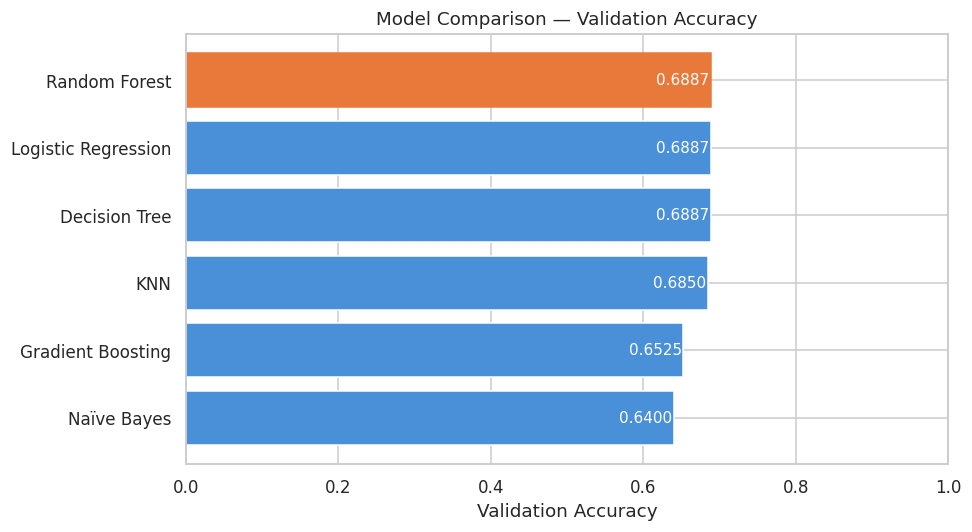

                     Validation Accuracy
Logistic Regression              0.68875
Decision Tree                    0.68875
Random Forest                    0.68875
KNN                              0.68500
Gradient Boosting                0.65250
Naïve Bayes                      0.64000

Best model: Decision Tree


In [21]:
# ─── Model Comparison ───────────────────────
results_df = pd.DataFrame.from_dict(results, orient="index", columns=["Validation Accuracy"])
results_df = results_df.sort_values("Validation Accuracy", ascending=True)

plt.figure(figsize=(9, 5))
bars = plt.barh(results_df.index, results_df["Validation Accuracy"],
                color="#4A90D9", edgecolor="white")

# Highlight best model
best_model_name = results_df["Validation Accuracy"].idxmax()
bars[-1].set_color("#E8793A")  # last bar = highest after sort

for bar, val in zip(bars, results_df["Validation Accuracy"]):
    plt.text(bar.get_width() - 0.002, bar.get_y() + bar.get_height()/2,
             f"{val:.4f}", va="center", ha="right", color="white", fontsize=10)

plt.xlabel("Validation Accuracy")
plt.title("Model Comparison — Validation Accuracy")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

print(results_df.sort_values("Validation Accuracy", ascending=False).to_string())
print(f"\nBest model: {best_model_name}")

---
## 7. Final Model — Retrain on Full Training Data & Generate Kaggle Submission

We retrain the best-performing model on the **entire** training set (not just the 80% split)
to maximise the information it learns before making predictions on the test set.

In [22]:
# ─── Retrain Best Model on Full Training Data ───
# Based on comparison above — update the model name here if needed
best_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
best_model.fit(X_train_full, y_train_full_enc)   # full training set, no validation split

# Predict on test set
y_test_pred_enc = best_model.predict(X_test_scaled)
y_test_pred     = le.inverse_transform(y_test_pred_enc)  # decode back to string labels

# Evaluate against the test set labels we have
print("=== Final Model — Test Set Performance ===")
print(f"Accuracy: {accuracy_score(y_test_enc, y_test_pred_enc):.4f}\n")
print(classification_report(y_test_enc, y_test_pred_enc, target_names=CLASS_NAMES))

# Build Kaggle submission file using the sample_submission IDs
sample_submission = pd.read_csv("sample_submission.csv")

# The sample has 5000 rows but test has 1000 — use only the first 1000 IDs
submission = pd.DataFrame({
    "ID": sample_submission["ID"].iloc[:len(y_test_pred)].values,
    "Predicted_Severity": y_test_pred
})

submission.to_csv("submission.csv", index=False)
print("\nSubmission file saved as 'submission.csv'")
print(submission.head(10))
print("\nPrediction distribution:")
print(submission["Predicted_Severity"].value_counts())

=== Final Model — Test Set Performance ===
Accuracy: 0.7000

               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.71      0.97      0.82       710
Severe Injury       0.31      0.03      0.06       249

     accuracy                           0.70      1000
    macro avg       0.34      0.34      0.29      1000
 weighted avg       0.58      0.70      0.60      1000


Submission file saved as 'submission.csv'
                                     ID Predicted_Severity
0  5ca30a05-b855-4cf3-915f-a92a6be7c010       Minor Injury
1  cc90ec30-fbb8-4f72-8814-8df3b82ea995       Minor Injury
2  a35b1df3-d476-4e21-b4be-54356572decb       Minor Injury
3  3f6e8e90-e5e7-4f49-93b2-64c1970839ce       Minor Injury
4  68829fcb-2211-40b4-a9a0-d06a8c6c970c       Minor Injury
5  59fea189-62d6-4820-a916-e501ecafb0b8       Minor Injury
6  c7d4ae29-e1d5-4ac8-8f1d-02f6dacafaaf       Minor Injury
7  51ae5acd-b2f6-47dd-814b-6ff04d726

In [23]:
from google.colab import files
files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>